# Center-Back Defensive Quality Analysis — 2024 Premier League

This notebook develops a data-driven **Duel Quality Index** for center-backs (CBs) using Wyscout event data from the 2024 Premier League season. The analysis follows three main phases:

1. **Data preparation** — load all match events, filter to CB actions, and join reference datasets (players, teams, minutes).
2. **Metric construction** — extract ground-duel events, detect fouls via temporal proximity, classify duel outcomes, and compute rate and per-90 metrics.
3. **Quality index** — normalise metrics to z-scores, examine correlations, build a weighted composite score, and rank all qualifying center-backs.

**Key output:** a ranked table of Premier League center-backs by composite duel quality, covering duel success, possession recovery, discipline, and activity volume.

In [1]:
%matplotlib inline

### Library Imports

We import the core libraries used throughout this analysis: `pandas` and `numpy` for data manipulation, `json` and `pathlib` / `os` for file I/O, `matplotlib` and `mplsoccer` for pitch visualisations, and `statsmodels` for any statistical modelling steps. `%matplotlib inline` ensures plots render directly in the notebook.

In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
# statistical fitting of models
import statsmodels.api as sm
import statsmodels.formula.api as smf
#opening data
import os
import pathlib
import warnings 

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

## Opening 
We load data 2024 PL England


In [3]:
folder = os.path.join(
    str(pathlib.Path().resolve().parents[0]),
    "data",
    "PL",
    "PL_2024_wyscout",
    "event_data"
)

files = os.listdir(folder)
len(files)

380

In [4]:

with open(folder + "/" + "5588080.json") as f:
    data = json.load(f)

# Option 1: If data is a list of events, use this:
data_test_df = pd.DataFrame(data["events"])
data_test_df

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2263270078,5588080,1H,0,4,00:00:04.610,5.610889,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 240445, 'name': 'Andreas Pereira', 'pos...","{'accurate': True, 'angle': 153, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
1,2263270076,5588080,1H,0,6,00:00:06.178,7.178286,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 38, 'y': 61}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 237269, 'name': 'S. Lukić', 'position':...","{'accurate': True, 'angle': 137, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
2,2263270077,5588080,1H,0,11,00:00:11.472,12.472906,2.263270e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 24, 'y': 81}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 286380, 'name': 'I. Diop', 'position': ...","{'accurate': True, 'angle': 9, 'height': None,...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
3,2263270079,5588080,1H,0,13,00:00:13.283,14.283666,2.263270e+09,"{'primary': 'duel', 'secondary': ['ground_duel...","{'x': 64, 'y': 91}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 225947, 'name': 'Adama Traoré', 'positi...",None,None,"{'opponent': {'id': 369589, 'name': 'Diogo Dal...",None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
4,2263270083,5588080,1H,0,14,00:00:14.199,15.199779,2.263270e+09,"{'primary': 'duel', 'secondary': ['defensive_d...","{'x': 36, 'y': 9}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 369589, 'name': 'Diogo Dalot', 'positio...",None,None,"{'opponent': {'id': 225947, 'name': 'Adama Tra...",None,None,None,"{'id': 2263270083, 'duration': '9.219295', 'ty..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606,2263271790,5588080,2H,94,20,01:34:20.113,5734.113979,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 41, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 397174, 'name': 'S. McTominay', 'positi...","{'accurate': True, 'angle': 180, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1607,2263271792,5588080,2H,94,21,01:34:21.292,5735.292554,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 30, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 488453, 'name': 'L. Martínez', 'positio...","{'accurate': True, 'angle': 142, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1608,2263271794,5588080,2H,94,25,01:34:25.879,5739.879353,2.263272e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 5, 'y': 56}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 344038, 'name': 'A. Onana', 'position':...","{'accurate': False, 'angle': 30, 'height': 'hi...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1609,2263271797,5588080,2H,94,32,01:34:32.461,5746.461904,NaN,"{'primary': 'game_interruption', 'secondary': ...","{'x': 55, 'y': 100}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 0, 'name': None, 'position': None}",None,None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."


In [5]:
# all_events = []

# for file in files:
    
#     path = os.path.join(folder, file)
    
#     with open(path) as f:
#         data = json.load(f)
    
#     events_df = pd.json_normalize(data["events"])
    
#     all_events.append(events_df)

# events_df = pd.concat(all_events, ignore_index=True)

### Loading All Match Event Files

We combine every match JSON file into a single DataFrame using `pd.concat` with a list comprehension. `pd.json_normalize` flattens each match's nested event objects into columns. `ignore_index=True` ensures the final index is contiguous. The resulting `events_df` contains every on-ball action for the entire 2024 Premier League season.

In [6]:
events_df = pd.concat(
    [
        pd.json_normalize(json.load(open(os.path.join(folder, f)))["events"])
        for f in files if f.endswith(".json")
    ],
    ignore_index=True
)

In [7]:
events_df.shape
events_df["matchId"].nunique()

380

## Extracting Center-Back Events

To begin constructing defensive quality metrics, we first isolate the events generated by center-backs during the season.

In [8]:
events_df["player.position"].unique()

<ArrowStringArray>
[   'CF',   'DMF',    'RB',   'LCB',   'RWF',     nan,   'LWF',    'GK',
    'LB',   'RCB', 'RCMF3', 'LCMF3',   'AMF',  'LDMF',  'RAMF',  'RDMF',
  'LAMF',    'LW',  'RCMF',  'LCMF',    'RW',   'LWB',  'LCB3',    'CB',
  'RCB3',   'RWB',   'LB5',    'SS',   'RB5']
Length: 29, dtype: str

In [9]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

cb_events = events_df[
    events_df["player.position"].isin(cb_positions)
]

cb_events

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent,location,aerialDuel.opponent,groundDuel.opponent
4,2384313775,5588197,1H,0,10,00:00:10.769,11.769625,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2384313788,5588197,1H,1,16,00:01:16.843,77.84337,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,2384313576,5588197,1H,1,17,00:01:17.539,78.539811,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,2384313792,5588197,1H,1,32,00:01:32.625,93.625916,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,2384313794,5588197,1H,1,39,00:01:39.547,100.547743,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630244,2395400792,5588229,2H,98,4,01:38:04.346,5965.346795,2.395401e+09,NaN,NaN,...,185.0,True,187.0,2.395401e+09,NaN,NaN,NaN,NaN,NaN,NaN
630246,2395400793,5588229,2H,98,6,01:38:06.058,5967.058901,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630248,2395400794,5588229,2H,98,10,01:38:10.693,5971.693504,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630252,2395400930,5588229,2H,98,22,01:38:22.427,5983.42787,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#load data - store it in data_england_df dataframe
data_england_df = pd.DataFrame()

### Single-Match Structure Exploration

To understand the schema of the Wyscout data, we open and inspect a single match JSON file in detail. This helps us identify relevant column names before we process the full dataset. `pd.json_normalize` flattens the nested event objects into a tabular format.

In [11]:
file_name = f'5588081.json'
path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "PL", "PL_2024_wyscout", "event_data", file_name)

with open(path) as f:
    data = json.load(f)

type(data)

dict

In [12]:
data.keys()

dict_keys(['meta', 'events', 'match', 'substitutions', 'teams', 'players'])

In [13]:
data_england_ = pd.DataFrame(data["events"])
data_england_

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 476382, 'name': 'D. Szoboszlai', 'posit...","{'accurate': True, 'angle': 173, 'height': Non...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 27, 'y': 55}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 214220, 'name': 'Alisson', 'position': ...","{'accurate': True, 'angle': -28, 'height': 'hi...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 73, 'y': 16}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 345621, 'name': 'Diogo Jota', 'position...",None,None,None,"{'opponent': {'id': 397163, 'name': 'A. Tuanze...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 27, 'y': 84}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 397163, 'name': 'A. Tuanzebe', 'positio...",None,None,None,"{'opponent': {'id': 345621, 'name': 'Diogo Jot...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 93, 'y': 14}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 431967, 'name': 'L. Díaz', 'position': ...","{'accurate': True, 'angle': -135, 'height': No...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 59, 'y': 41}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 460321, 'name': 'J. Taylor', 'position'...","{'accurate': False, 'angle': -12, 'height': 'h...",None,None,None,None,None,"{'id': 2264029735, 'duration': '29.0688565', '..."
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,"{'primary': 'interception', 'secondary': ['for...","{'x': 19, 'y': 66}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 631619, 'name': 'C. Bradley', 'position...","{'accurate': True, 'angle': -7, 'height': 'hig...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,"{'primary': 'pass', 'secondary': ['lateral_pas...","{'x': 34, 'y': 63}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 535824, 'name': 'R. Gravenberch', 'posi...","{'accurate': True, 'angle': -76, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 42, 'y': 17}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 344181, 'name': 'K. Tsimikas', 'positio...","{'accurate': True, 'angle': -24, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."


In [14]:
data_england_df = pd.json_normalize(data["events"])
data_england_df

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,shot.goalkeeper,infraction.yellowCard,infraction.redCard,infraction.type,infraction.opponent.id,infraction.opponent.name,infraction.opponent.position,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
data_england_df.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack.withShot',
       'possession.attack.withShotOnGoal', 'possession.attack.withGoal',
       'possession

## Players

### Loading Reference Data

In addition to the raw event log, we load four supporting datasets stored as Parquet files: **players** (player metadata and positions), **teams** (club information), **minutes** (playing time per player per match), and **matches** (fixture metadata). These will be joined to the events data to enrich player-level summaries.

In [16]:
parquet_path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "PL", "PL_2024_wyscout/")

players_england_df = pd.read_parquet(parquet_path + "players.parquet")
players_england_df

,player_id,short_name,first_name,last_name,birth_date,height,weight,passport,birth_country,image_url,gender,foot,role,team_id,season_id
0,1096014,T. Edozie,Tom,Edozie,2006-05-18,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,22988,189908
1,1050460,J. Monga,Jeremy,Monga,2009-07-10,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,25891,189908
2,1046087,M. Mane,Mateus,Mane,2007-09-16,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,2339,189908
3,961676,Y. Konak,Yunus Emre,Konak,2006-01-10,181,72,Turkey,Turkey,https://cdn5.wyscout.com/photos/players/public...,male,right,Midfielder,1669,189908
4,960198,J. Moore,Jayden,Moore,1970-01-01,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,22977,189908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,543978,D. Núñez,Darwin Gabriel,Núñez Ribeiro,1999-06-24,186,80,Uruguay,Uruguay,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,1612,189908
680,544911,N. Patterson,Nathan,Patterson,2001-10-16,183,72,Scotland,Scotland,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1623,189908
681,545267,R. Drăgușin,Radu,Drăgușin,2002-02-03,191,82,Romania,Romania,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1624,189908
682,545295,H. Graczyk,Hubert,Graczyk,2003-02-28,187,76,England,Poland,https://cdn5.wyscout.com/photos/players/public...,male,right,Goalkeeper,22975,189908


In [17]:
players_england_df.columns

Index(['player_id', 'short_name', 'first_name', 'last_name', 'birth_date',
       'height', 'weight', 'passport', 'birth_country', 'image_url', 'gender',
       'foot', 'role', 'team_id', 'season_id'],
      dtype='str')

In [18]:
teams_england_df = pd.read_parquet(parquet_path + "teams.parquet")
teams_england_df

,team_id,name,official_name,country,image_url,gender,season_id
0,1609,Arsenal,Arsenal FC,England,https://cdn5.wyscout.com/photos/team/public/21...,male,189908
1,1610,Chelsea,Chelsea FC,England,https://cdn5.wyscout.com/photos/team/public/25...,male,189908
2,1611,Manchester United,Manchester United FC,England,https://cdn5.wyscout.com/photos/team/public/22...,male,189908
3,1612,Liverpool,Liverpool FC,England,https://cdn5.wyscout.com/photos/team/public/24...,male,189908
4,1613,Newcastle United,Newcastle United FC,England,https://cdn5.wyscout.com/photos/team/public/36...,male,189908
5,1614,Aston Villa,Aston Villa FC,England,https://cdn5.wyscout.com/photos/team/public/32...,male,189908
6,1616,Fulham,Fulham FC,England,https://cdn5.wyscout.com/photos/team/public/29...,male,189908
7,1619,Southampton,Southampton FC,England,https://cdn5.wyscout.com/photos/team/public/30...,male,189908
8,1623,Everton,Everton FC,England,https://cdn5.wyscout.com/photos/team/public/37...,male,189908
9,1624,Tottenham Hotspur,Tottenham Hotspur FC,England,https://cdn5.wyscout.com/photos/team/public/26...,male,189908


In [19]:
teams_england_df.columns

Index(['team_id', 'name', 'official_name', 'country', 'image_url', 'gender',
       'season_id'],
      dtype='str')

In [20]:
minutes_england_df = pd.read_parquet(parquet_path + "minutes.parquet")

In [21]:
matches_england_df = pd.read_parquet(parquet_path + "matches.parquet")
matches_england_df

,match_id,competition_id,season_id,date,label,gameweek,home_team_id,away_team_id,home_team_name,away_team_name,home_team_score,away_team_score,status,home_coach_id,away_coach_id,competition,season
0,5588368,364,189908,2025-04-16 20:30:00,"Newcastle United - Crystal Palace, 5-0",29,1613,1628,Newcastle United,Crystal Palace,5,0,Played,8934,753418,364,2024
1,5588095,364,189908,2024-08-25 17:30:00,"Liverpool - Brentford, 2-0",2,1612,1669,Liverpool,Brentford,2,0,Played,753720,135095,364,2024
2,5588282,364,189908,2025-01-15 20:30:00,"Everton - Aston Villa, 0-1",21,1623,1614,Everton,Aston Villa,0,1,Played,8235,3265,364,2024
3,5588329,364,189908,2025-02-15 16:00:00,"West Ham United - Brentford, 0-1",25,1633,1669,West Ham United,Brentford,0,1,Played,51607,135095,364,2024
4,5588443,364,189908,2025-05-19 21:00:00,"Brighton - Liverpool, 3-2",37,1651,1612,Brighton,Liverpool,3,2,Played,18554,753720,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,5588199,364,189908,2024-11-24 15:00:00,"Southampton - Liverpool, 2-3",12,1619,1612,Southampton,Liverpool,2,3,Played,641939,753720,364,2024
376,5588212,364,189908,2024-12-05 21:15:00,"Bournemouth - Tottenham Hotspur, 1-0",14,1659,1624,Bournemouth,Tottenham Hotspur,1,0,Played,575112,61546,364,2024
377,5588234,364,189908,2024-12-14 16:00:00,"Liverpool - Fulham, 2-2",16,1612,1616,Liverpool,Fulham,2,2,Played,753720,71037,364,2024
378,5588354,364,189908,2025-03-08 16:00:00,"Liverpool - Southampton, 3-1",28,1612,1619,Liverpool,Southampton,3,1,Played,753720,753322,364,2024


In [22]:
matches_england_df.columns

Index(['match_id', 'competition_id', 'season_id', 'date', 'label', 'gameweek',
       'home_team_id', 'away_team_id', 'home_team_name', 'away_team_name',
       'home_team_score', 'away_team_score', 'status', 'home_coach_id',
       'away_coach_id', 'competition', 'season'],
      dtype='str')

In [23]:
# Debug: Check what type data is and print a sample
print(f"Data type: {type(data)}")
if isinstance(data, dict):
    print(f"Keys: {list(data.keys())}")
    # Print first few items of each key to understand structure
    for key in list(data.keys())[:3]:
        print(f"\n{key}: {type(data[key])}")
        if isinstance(data[key], list) and len(data[key]) > 0:
            print(f"First item: {data[key][0]}")
elif isinstance(data, list):
    print(f"List length: {len(data)}")
    if len(data) > 0:
        print(f"First item type: {type(data[0])}")
        print(f"First item: {data[0]}")

Data type: <class 'dict'>
Keys: ['meta', 'events', 'match', 'substitutions', 'teams', 'players']

meta: <class 'list'>

events: <class 'list'>
First item: {'id': 2264027646, 'matchId': 5588081, 'matchPeriod': '1H', 'minute': 0, 'second': 0, 'matchTimestamp': '00:00:00.654', 'videoTimestamp': '1.654401', 'relatedEventId': 2264027649, 'type': {'primary': 'pass', 'secondary': ['back_pass', 'short_or_medium_pass']}, 'location': {'x': 51, 'y': 50}, 'team': {'id': 1612, 'name': 'Liverpool'}, 'opponentTeam': {'id': 1634, 'name': 'Ipswich Town'}, 'player': {'id': 476382, 'name': 'D. Szoboszlai', 'position': 'AMF'}, 'pass': {'accurate': True, 'angle': 173, 'height': None, 'length': 25, 'recipient': {'id': 214220, 'name': 'Alisson', 'position': 'GK'}, 'endLocation': {'x': 27, 'y': 55}}, 'shot': None, 'groundDuel': None, 'aerialDuel': None, 'infraction': None, 'carry': None, 'possession': {'id': 2264027646, 'duration': '25.3317015', 'types': ['attack'], 'eventsNumber': 15, 'eventIndex': 0, 'start

# Qualities
By filtering the event dataset using these labels, we obtain a subset of events corresponding only to center-backs. This filtered dataset will be used to compute basic defensive metrics such as:

- **Duel dominance** – ability to win ground and aerial duels  
- **Aerial ability** – effectiveness in aerial challenges  
- **Defensive aggression** – frequency of engaging in defensive duels  

These metrics will later be normalized and combined into a simple defensive quality index, which will serve as a first step toward identifying center-back archetypes.

### Exploring CB Event Structure

Before calculating metrics, we explore the available columns and infraction fields in the center-back event subset. Understanding which fields exist (and their unique values) is essential for correctly identifying fouls, yellow cards, and red cards that occurred during defensive actions.

In [24]:
cb_events.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack', 'pass',
       'possession.attack.withShot', 'possession.attack.withShotOnGoal',
       'possession.

In [25]:
cb_events["infraction.type"].unique()

<ArrowStringArray>
[               nan,     'regular_foul', 'out_of_play_foul',
        'hand_foul',   'late_card_foul',     'protest_foul',
   'time_lost_foul',  'simulation_foul']
Length: 8, dtype: str

In [26]:
cb_events.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack', 'pass',
       'possession.attack.withShot', 'possession.attack.withShotOnGoal',
       'possession.

In [27]:
cb_events["infraction.yellowCard"].unique()

array([nan, False, True], dtype=object)

In [28]:
cb_events["infraction.redCard"].unique()

array([nan, False, True], dtype=object)

### Ground Duels

### Filtering to Defensive Ground Duels

From all center-back events, we isolate those tagged as **defensive ground duels** (`groundDuel.duelType == 'defensive'`). These are the one-on-one challenges where a CB attempts to stop an opponent carrying the ball. We also collect foul events separately so we can later link them back to the duel that triggered them.

In [29]:
duel_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "infraction.type",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "groundDuel.takeOn",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name', 'groundDuel.opponent.position',
]
ground_duels = cb_events[
    (cb_events["groundDuel.duelType"] == "defensive_duel") | (cb_events["infraction.type"] == 'regular_foul')
]
ground_duels[duel_cols].head(20)

,player.id,player.name,matchTimestamp,infraction.type,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,groundDuel.takeOn,groundDuel.opponent.id,groundDuel.opponent.name,groundDuel.opponent.position
76,136441,B. Davies,00:03:53.853,NaN,defensive_duel,False,False,False,447205.0,P. Foden,RWF
80,136441,B. Davies,00:04:01.926,NaN,defensive_duel,False,False,False,0.0,NaN,NaN
201,545267,R. Drăgușin,00:10:42.669,NaN,defensive_duel,False,False,True,661732.0,Savinho,LWF
327,9380,J. Stones,00:17:17.438,NaN,defensive_duel,True,False,True,286831.0,D. Solanke,CF
385,9380,J. Stones,00:22:05.043,NaN,defensive_duel,False,False,False,286831.0,D. Solanke,CF
392,9380,J. Stones,00:22:08.796,NaN,defensive_duel,False,False,False,286831.0,D. Solanke,CF
393,9380,J. Stones,00:22:09.414,regular_foul,NaN,NaN,NaN,NaN,NaN,NaN,NaN
485,136441,B. Davies,00:26:05.753,NaN,defensive_duel,False,False,False,0.0,NaN,NaN
740,9380,J. Stones,00:40:51.398,NaN,defensive_duel,True,False,False,286831.0,D. Solanke,CF
819,545267,R. Drăgușin,00:43:53.041,NaN,defensive_duel,False,False,True,568412.0,J. Gvardiol,LB


In [30]:
print("ground duels unique", ground_duels["groundDuel.duelType"].unique())
print("ground duel infraction type", ground_duels["infraction.type"].unique())
print("ground duels kept possession unique", ground_duels["groundDuel.keptPossession"].unique())
print("ground duels progressed with ball", ground_duels["groundDuel.progressedWithBall"].unique())
print("ground duels stopped progress unique", ground_duels["groundDuel.stoppedProgress"].unique())
print("ground duels recovered possession unique", ground_duels["groundDuel.recoveredPossession"].unique())

ground duels unique <ArrowStringArray>
['defensive_duel', nan]
Length: 2, dtype: str
ground duel infraction type <ArrowStringArray>
[nan, 'regular_foul']
Length: 2, dtype: str
ground duels kept possession unique [None nan]
ground duels progressed with ball [None nan]
ground duels stopped progress unique [False True nan]
ground duels recovered possession unique [False nan True]


## Ground Duel Foul Detection

We need to identify which defensive duels resulted in fouls to properly assess defensive quality. The challenge is that fouls are recorded as separate events from the duel itself.

### Why we do this:

1. **Separate event recording**: In the Wyscout data, a defensive duel and the resulting foul are logged as two distinct events
2. **Quality assessment**: A duel that results in a foul indicates aggressive but potentially flawed defensive execution
3. **Temporal proximity**: We only link duels to fouls if they occur within 1.3 second of each other by the same player

In [31]:
def timestamp_to_seconds(ts):
    """Convert HH:MM:SS.milliseconds to total seconds"""
    if pd.isna(ts):
        return np.nan
    h, m, s = ts.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)


# Work on a copy so the original ground_duels DataFrame is preserved
ground_duels_with_fouls = ground_duels.copy()

ground_duels_with_fouls["next_event_foul"] = (
    ground_duels["infraction.type"].shift(-1) == "regular_foul"
)

ground_duels_with_fouls["next_player_same"] = (
    ground_duels["player.id"] == ground_duels["player.id"].shift(-1)
)

ground_duels_with_fouls["foul_timestamp_seconds"] = ground_duels["matchTimestamp"].apply(timestamp_to_seconds).shift(-1)
ground_duels_with_fouls["match_timestamp_seconds"] = ground_duels["matchTimestamp"].apply(timestamp_to_seconds)

ground_duels_with_fouls["time_diff"] = (
    ground_duels_with_fouls["foul_timestamp_seconds"] - ground_duels_with_fouls["match_timestamp_seconds"]
)

ground_duels_with_fouls["yellowCard_shift"] = ground_duels_with_fouls["infraction.yellowCard"].shift(-1)
ground_duels_with_fouls["redCard_shift"] = ground_duels_with_fouls["infraction.redCard"].shift(-1)

ground_duels_with_fouls["duel_resulted_foul"] = (
    ground_duels_with_fouls["next_event_foul"] &
    ground_duels_with_fouls["next_player_same"] &
    (ground_duels_with_fouls["time_diff"] <= 1.3)
)

ground_duels_with_fouls["yellowCard"] = ground_duels_with_fouls["yellowCard_shift"].where(
    ground_duels_with_fouls["duel_resulted_foul"],
    False
)

ground_duels_with_fouls["redCard"] = ground_duels_with_fouls["redCard_shift"].where(
    ground_duels_with_fouls["duel_resulted_foul"],
    False
)

# Drop rows where infraction.type is regular_foul
ground_duels_with_fouls = ground_duels_with_fouls[ground_duels_with_fouls["infraction.type"] != "regular_foul"]

# After the duel_resulted_foul flag
ground_duels_with_fouls["unsuccessful_duel"] = (
    ~ground_duels_with_fouls["duel_resulted_foul"] &
    (ground_duels_with_fouls["groundDuel.stoppedProgress"] == False) &
    (ground_duels_with_fouls["groundDuel.recoveredPossession"] == False)
)

duel_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "duel_resulted_foul",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "unsuccessful_duel",
    "groundDuel.takeOn",
    "yellowCard",
    "redCard",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name',
]

ground_duels_with_fouls[duel_cols].head(20)

,player.id,player.name,matchTimestamp,duel_resulted_foul,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,unsuccessful_duel,groundDuel.takeOn,yellowCard,redCard,groundDuel.opponent.id,groundDuel.opponent.name
76,136441,B. Davies,00:03:53.853,False,defensive_duel,False,False,True,False,False,False,447205.0,P. Foden
80,136441,B. Davies,00:04:01.926,False,defensive_duel,False,False,True,False,False,False,0.0,NaN
201,545267,R. Drăgușin,00:10:42.669,False,defensive_duel,False,False,True,True,False,False,661732.0,Savinho
327,9380,J. Stones,00:17:17.438,False,defensive_duel,True,False,False,True,False,False,286831.0,D. Solanke
385,9380,J. Stones,00:22:05.043,False,defensive_duel,False,False,True,False,False,False,286831.0,D. Solanke
392,9380,J. Stones,00:22:08.796,True,defensive_duel,False,False,False,False,False,False,286831.0,D. Solanke
485,136441,B. Davies,00:26:05.753,False,defensive_duel,False,False,True,False,False,False,0.0,NaN
740,9380,J. Stones,00:40:51.398,False,defensive_duel,True,False,False,False,False,False,286831.0,D. Solanke
819,545267,R. Drăgușin,00:43:53.041,False,defensive_duel,False,False,True,True,False,False,568412.0,J. Gvardiol
848,9380,J. Stones,00:45:41.386,False,defensive_duel,False,False,True,False,False,False,0.0,NaN


### Classifying Duel Outcomes

Each duel is assigned exactly one outcome label using a priority order:

1. **`foul`** — if the duel triggered a foul (detected via temporal proximity).
2. **`won_possession`** — if the defender directly recovered the ball.
3. **`stopped_progress`** — if the defender halted the opponent without winning the ball.
4. **`lost_duel`** — if none of the above apply (opponent retained possession).

Fouls take priority because a duel that results in a foul cannot simultaneously be counted as a defensive success.

In [32]:
def classify_duel(row):

    if row["duel_resulted_foul"]:
        return "foul"

    if row["groundDuel.recoveredPossession"]:
        return "won_possession"

    if row["groundDuel.stoppedProgress"]:
        return "stopped_progress"

    if row["unsuccessful_duel"]:
        return "lost_duel"

    return "other"

ground_duels_with_fouls["duel_outcome"] = ground_duels_with_fouls.apply(classify_duel, axis=1)

In [33]:
ground_duels_with_fouls

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,foul_timestamp_seconds,match_timestamp_seconds,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,unsuccessful_duel,duel_outcome
76,2384313826,5588197,1H,3,53,00:03:53.853,234.853653,2.384315e+09,NaN,NaN,...,241.926,233.853,8.073,NaN,NaN,False,False,False,True,lost_duel
80,2384313827,5588197,1H,4,1,00:04:01.926,242.926923,2.384314e+09,NaN,NaN,...,642.669,241.926,400.743,NaN,NaN,False,False,False,True,lost_duel
201,2384313920,5588197,1H,10,42,00:10:42.669,643.669719,2.384314e+09,NaN,NaN,...,1037.438,642.669,394.769,NaN,NaN,False,False,False,True,lost_duel
327,2384313750,5588197,1H,17,17,00:17:17.438,1038.438204,2.384314e+09,NaN,NaN,...,1325.043,1037.438,287.605,NaN,NaN,False,False,False,False,stopped_progress
385,2384313808,5588197,1H,22,5,00:22:05.043,1326.043148,2.384314e+09,NaN,NaN,...,1328.796,1325.043,3.753,NaN,NaN,False,False,False,True,lost_duel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630109,2395400879,5588229,2H,89,31,01:29:31.043,5452.043937,2.395401e+09,NaN,NaN,...,5506.747,5371.043,135.704,NaN,NaN,False,False,False,False,won_possession
630144,2395400695,5588229,2H,91,46,01:31:46.747,5587.747459,2.395401e+09,NaN,NaN,...,5510.951,5506.747,4.204,False,False,False,False,False,True,lost_duel
630165,2395400708,5588229,2H,93,46,01:33:46.641,5707.641194,2.395401e+09,NaN,NaN,...,5661.854,5626.641,35.213,NaN,NaN,False,False,False,False,stopped_progress
630176,2395400717,5588229,2H,94,21,01:34:21.854,5742.854079,2.395401e+09,NaN,NaN,...,5681.795,5661.854,19.941,NaN,NaN,False,False,False,False,won_possession


In [34]:
ground_duels_with_fouls[
    ["player.name",
     "groundDuel.duelType",
     "groundDuel.stoppedProgress",
     "groundDuel.recoveredPossession",
     "duel_resulted_foul",
     "unsuccessful_duel",
     "duel_outcome",
     "yellowCard",
     "redCard",]
].head(20)

,player.name,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,duel_resulted_foul,unsuccessful_duel,duel_outcome,yellowCard,redCard
76,B. Davies,defensive_duel,False,False,False,True,lost_duel,False,False
80,B. Davies,defensive_duel,False,False,False,True,lost_duel,False,False
201,R. Drăgușin,defensive_duel,False,False,False,True,lost_duel,False,False
327,J. Stones,defensive_duel,True,False,False,False,stopped_progress,False,False
385,J. Stones,defensive_duel,False,False,False,True,lost_duel,False,False
392,J. Stones,defensive_duel,False,False,True,False,foul,False,False
485,B. Davies,defensive_duel,False,False,False,True,lost_duel,False,False
740,J. Stones,defensive_duel,True,False,False,False,stopped_progress,False,False
819,R. Drăgușin,defensive_duel,False,False,False,True,lost_duel,False,False
848,J. Stones,defensive_duel,False,False,False,True,lost_duel,False,False


In [35]:
ground_duels_with_fouls[
    (ground_duels_with_fouls["player.id"] == 297957) &
    ((ground_duels_with_fouls["yellowCard"] == True) | (ground_duels_with_fouls["yellowCard"] == False))
]

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,foul_timestamp_seconds,match_timestamp_seconds,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,unsuccessful_duel,duel_outcome
905,2384314341,5588197,2H,45,44,00:45:44.721,2948.721372,2.384314e+09,NaN,NaN,...,3015.926,2744.721,271.205,NaN,NaN,False,False,False,False,stopped_progress
996,2384314399,5588197,2H,50,15,00:50:15.926,3219.926665,2.384314e+09,NaN,NaN,...,3016.453,3015.926,0.527,False,False,True,False,False,False,foul
1141,2384314570,5588197,2H,58,9,00:58:09.914,3693.914099,2.384315e+09,NaN,NaN,...,3566.226,3489.914,76.312,NaN,NaN,False,False,False,False,won_possession
1269,2384314750,5588197,2H,65,13,01:05:13.452,4117.452223,2.384315e+09,NaN,NaN,...,3920.987,3913.452,7.535,NaN,NaN,False,False,False,True,lost_duel
1273,2384314751,5588197,2H,65,20,01:05:20.987,4124.987623,2.384315e+09,NaN,NaN,...,4075.419,3920.987,154.432,NaN,NaN,False,False,False,True,lost_duel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513180,2393256013,5588204,2H,89,13,01:29:13.427,5550.427499,2.393256e+09,NaN,NaN,...,5390.409,5353.427,36.982,NaN,NaN,False,False,False,False,stopped_progress
543253,2392916703,5588137,1H,39,35,00:39:35.001,2376.00104,2.392917e+09,NaN,NaN,...,3189.107,2375.001,814.106,NaN,NaN,False,False,False,False,won_possession
544100,2392916860,5588137,2H,88,6,01:28:06.806,5374.806928,2.392917e+09,NaN,NaN,...,5372.865,5286.806,86.059,NaN,NaN,False,False,False,True,lost_duel
610232,2395735155,5588116,1H,9,52,00:09:52.325,593.325066,2.395736e+09,NaN,NaN,...,661.118,592.325,68.793,NaN,NaN,False,False,False,False,stopped_progress


### Aggregating Duel Outcomes Per Player

We group events by player and pivot the `duel_outcome` column to get a count of each outcome type per player (won possession, stopped progress, foul, lost duel). A `total_duels` column is added by summing across all outcome types. This player-level summary table is the foundation for all subsequent metric calculations.

In [36]:
duel_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_outcome"] 
    .value_counts()
    .unstack(fill_value=0)
)
duel_summary["total_duels"] = duel_summary.sum(axis=1)
duel_summary = duel_summary[
    ["total_duels", "won_possession", "stopped_progress", "foul", "lost_duel"]
]
duel_summary


,duel_outcome,total_duels,won_possession,stopped_progress,foul,lost_duel
player.id,player.name,,,,,
47,J. Veltman,3,1,1,0,1
370,V. van Dijk,149,58,53,2,36
1712,K. Tete,7,1,4,0,2
7914,J. Evans,19,4,4,1,10
7919,M. Keane,47,12,18,0,17
...,...,...,...,...,...,...
777938,Dean Huijsen,153,42,69,2,40
783644,J. Simpson-Pusey,5,2,1,0,2
816274,J. Sanda,1,0,0,0,1


In [37]:
duel_summary.loc[297957]

duel_outcome,total_duels,won_possession,stopped_progress,foul,lost_duel
player.name,,,,,
M. Akanji,84,16,29,5,34


### Foul and Card Summary Tables

In addition to the duel outcome breakdown, we extract two focused summaries: the total number of fouls committed during duels (`foul_summary`) and the total yellow and red cards received (`card_summary`). These will be merged into the main summary to support discipline metrics.

In [38]:
foul_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_resulted_foul"]
    .sum()
    .rename("fouls_from_duels")
)

foul_summary

player.id  player.name     
47         J. Veltman          0
370        V. van Dijk         2
1712       K. Tete             0
7914       J. Evans            1
7919       M. Keane            0
                              ..
777938     Dean Huijsen        2
783644     J. Simpson-Pusey    0
816274     J. Sanda            0
822917     J. Acheampong       0
933026     A. Heaven           0
Name: fouls_from_duels, Length: 155, dtype: int64

In [39]:
card_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])
    .agg(
        yellow_cards=("yellowCard", "sum"),
        red_cards=("redCard", "sum")
    )
)

card_summary.loc[297957]


,yellow_cards,red_cards
player.name,,
M. Akanji,1,0


In [40]:
duel_summary = duel_summary.join(card_summary).fillna(0)

In [41]:
duel_summary.head(40)

,,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards
player.id,player.name,,,,,,,
47,J. Veltman,3,1,1,0,1,0,0
370,V. van Dijk,149,58,53,2,36,0,0
1712,K. Tete,7,1,4,0,2,0,0
7914,J. Evans,19,4,4,1,10,0,0
7919,M. Keane,47,12,18,0,17,0,0
7953,C. Coady,58,19,19,3,17,1,0
8135,L. Shaw,20,8,8,1,3,0,0
8136,J. Stephens,96,24,40,2,30,1,0
8221,J. Ward,10,1,4,3,2,0,0


## Calculate the Minutes for Players

To normalise duel statistics by playing time, we need to know how many minutes each center-back played across the season. We load a pre-processed minutes dataset, fix any data errors (negative values), and aggregate total minutes per player — filtering to only the CB position labels used throughout this analysis.

In [42]:
minutes_england_df.position_provider.unique()

<ArrowStringArray>
[ 'RAMF',   'AMF',   'RCB',    'RB',  'LDMF',    'GK',    'CF',  'RDMF',
    'LB',   'LCB',  'LAMF',    'SS',    'RW',    'LW',  'RCMF',  'LCMF',
   'RWF', 'LCMF3',   'LWF', 'RCMF3',   'DMF',   'RWB',    'CB',   'LWB',
  'LCB3',  'RCB3',   'RB5',   'LB5',      '']
Length: 29, dtype: str

In [43]:
minutes_england_df[minutes_england_df["player_id"] == 543873].head()

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
8933,543873,28,LCB,Central Defender,16,1651,5588372,False,0,False,0,0,72,0,18,0,False,364,2024
9786,543873,1,RCB,Central Defender,16,1651,5588401,False,0,False,0,0,110,0,-20,0,False,364,2024


In [44]:
minutes_england_df[minutes_england_df["minutes"] < 0]

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
30,275780,3,LCMF,Midfielder,6,1616,5588080,False,0,False,0,0,91,0,-1,0,False,364,2024
31,622234,3,SS,Striker,28,1616,5588080,False,0,False,0,0,91,0,-1,0,False,364,2024
305,447955,7,RB,Full Back,24,1624,5588089,False,0,False,0,0,92,0,-2,0,False,364,2024
306,377071,7,LW,Winger,9,1624,5588089,False,0,False,0,0,92,0,-2,0,False,364,2024
398,504249,6,RW,Winger,20,1642,5588097,False,0,False,0,0,92,0,-2,0,False,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11304,732238,4,LAMF,Winger,8,1659,5588450,False,0,False,0,0,91,0,-1,0,False,364,2024
11305,956089,4,,,47,1659,5588450,False,0,False,0,0,91,0,-1,0,False,364,2024
11306,824351,4,,,20,1659,5588450,False,0,False,0,0,91,0,-1,0,False,364,2024
11416,644809,2,LW,Winger,11,1628,5588453,False,0,False,0,0,93,0,-3,0,False,364,2024


In [45]:
minutes_england_df["minutes"] = minutes_england_df["minutes"].clip(lower=0)

In [46]:
minutes_england_df[minutes_england_df["minutes"] < 0]

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season


In [47]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

minutes_per_player = (
    minutes_england_df[minutes_england_df["position_provider"].isin(cb_positions)]
    .groupby("player_id", as_index=False)["minutes"]
    .sum()
)

## Rate Metrics

Raw duel counts depend heavily on how many matches a player featured in. Rate metrics express outcomes as proportions of total duels, making performance comparable across players regardless of how often they played.

### Merging Playing Minutes into the Duel Summary

To calculate per-90 stats and apply a minimum-minutes filter later, we join the player-level minutes data into the duel summary. A left join is used so that players with duels but no minutes record (data quality issues) are retained and can be inspected or dropped downstream.

In [48]:
duel_summary = duel_summary.reset_index().merge(
    minutes_per_player,
    left_on="player.id",
    right_on="player_id",
    how="left"
).set_index(["player.id", "player.name"])

# Reorder columns to put minutes first
cols = ["minutes"] + [col for col in duel_summary.columns if col != "minutes" and col != "player_id"]
duel_summary = duel_summary[cols]

### Computing Rate-Based Metrics

We now calculate four proportional metrics for each player, all expressed as a fraction of their total ground duels:

- **`duel_success_rate`**: share of duels where the player won possession or stopped the opponent's progress.
- **`possession_win_rate`**: share of duels where the player directly recovered the ball.
- **`foul_rate`**: share of duels that ended in a foul.
- **`discipline`**: complement of foul rate — higher means cleaner defending.

In [49]:
duel_summary["duel_success_rate"] = (
    duel_summary["won_possession"] + duel_summary["stopped_progress"]
) / duel_summary["total_duels"]

In [50]:
duel_summary["possession_win_rate"] = (
    duel_summary["won_possession"] / duel_summary["total_duels"]
)


In [51]:
duel_summary["foul_rate"] = duel_summary["foul"] / duel_summary["total_duels"]
duel_summary["discipline"] = 1 - duel_summary["foul_rate"]

#### Card Discipline Metric

Beyond raw foul rate, we also track card severity. A yellow card is weighted as 1 and a red card as 3 (reflecting its much greater game impact). `card_discipline` is computed as `1 − (yellows + 3×reds) / total_duels`, so higher values indicate a player who contests duels without accumulating dangerous bookings.

In [52]:
duel_summary["card_discipline"] = 1 - ((duel_summary["yellow_cards"] + 3*duel_summary["red_cards"]) / duel_summary["total_duels"])

In [53]:
duel_summary = duel_summary.sort_values("minutes", ascending=False)
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
656446,M. Kerkez,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
658798,R. Lewis,NaN,5,0,3,1,1,1,0,0.600000,0.000000,0.200000,0.800000,0.8


In [54]:
duel_summary[duel_summary["minutes"].isna()]

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
134717,L. Trossard,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0
217031,T. Partey,NaN,3,1,1,0,1,0,0,0.666667,0.333333,0.0,1.0,1.0
285403,T. Souček,NaN,4,2,0,0,2,0,0,0.500000,0.500000,0.0,1.0,1.0
302518,L. Cook,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.0,1.0,1.0
344040,Marc Cucurella,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.0,1.0,1.0
346125,D. Brooks,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0
361807,R. Bentancur,NaN,3,1,1,0,1,0,0,0.666667,0.333333,0.0,1.0,1.0
491413,D. Muñoz,NaN,5,1,3,0,1,0,0,0.800000,0.200000,0.0,1.0,1.0
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0


In [55]:
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
656446,M. Kerkez,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
658798,R. Lewis,NaN,5,0,3,1,1,1,0,0.600000,0.000000,0.200000,0.800000,0.8


### Individual Player Spot-Check (Muñoz)

As a sanity check, we inspect the full duel-by-duel record for a specific player (César Muñoz, id 491413). This helps validate that the foul-detection logic and outcome classification are working as expected before we proceed to aggregate statistics.

In [56]:
munoz_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "player.position",
    "duel_resulted_foul",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "unsuccessful_duel",
    "groundDuel.takeOn",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name',
]
munoz = ground_duels_with_fouls[ground_duels_with_fouls["player.id"] == 491413]
munoz[munoz_cols]

,player.id,player.name,matchTimestamp,player.position,duel_resulted_foul,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,unsuccessful_duel,groundDuel.takeOn,groundDuel.opponent.id,groundDuel.opponent.name
217714,491413,D. Muñoz,01:13:57.932,RCB3,False,defensive_duel,True,False,False,False,729649.0,A. Fatawu
217753,491413,D. Muñoz,01:15:24.987,RCB3,False,defensive_duel,True,True,False,False,707333.0,V. Kristiansen
217798,491413,D. Muñoz,01:17:34.625,RCB3,False,defensive_duel,False,False,True,False,25571.0,J. Ayew
408122,491413,D. Muñoz,01:25:14.038,RCB3,False,defensive_duel,True,False,False,False,370937.0,Bruno Guimarães
514742,491413,D. Muñoz,01:30:31.839,RCB3,False,defensive_duel,True,False,False,False,333618.0,K. Ajer


## Volume Metrics

Rate metrics (success rates, discipline) tell us *how well* a player performs in duels, but not *how often* they get involved. Volume metrics capture duel frequency and interception activity per 90 minutes, adding an activity dimension to the quality profile.

### Per-90 Volume Metrics

Raw counts (e.g. total duels) are biased towards players who played more minutes. To make comparisons fair, we normalise volume statistics to a **per-90-minute** basis: dividing by total minutes played and multiplying by 90. This tells us how active and impactful a player is relative to their playing time.

In [57]:
duel_summary["duels_per90"] = duel_summary["total_duels"] / duel_summary["minutes"] * 90
duel_summary["interceptions_per90"] = (duel_summary["won_possession"] + duel_summary["stopped_progress"]) / duel_summary["minutes"] * 90
duel_summary["stops_per90"] = duel_summary["stopped_progress"] / duel_summary["minutes"] * 90

### Applying Minimum Playing-Time and Volume Thresholds

Players with very few duels or limited minutes can produce extreme, unreliable metric values. We remove rows with missing data and apply two minimum thresholds: **≥ 30 total duels** and **≥ 350 minutes played**. This ensures only players with a meaningful sample size are included in the quality ranking.

In [58]:
duel_summary.dropna(inplace=True)
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline,duels_per90,interceptions_per90,stops_per90
player.id,player.name,,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061,5.605263,3.815789,2.342105
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301,3.923559,2.660496,1.558674
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0,4.027027,3.000000,1.432432
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565,4.972973,3.216216,1.918919
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0,4.243243,3.027027,1.675676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263803,T. Castagne,13.0,12,2,4,0,6,0,0,0.500000,0.166667,0.000000,1.000000,1.0,83.076923,41.538462,27.692308
816274,J. Sanda,12.0,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0,7.500000,0.000000,0.000000
447963,B. Johnson,10.0,3,0,1,0,2,0,0,0.333333,0.000000,0.000000,1.000000,1.0,27.000000,9.000000,9.000000


In [59]:
duel_summary = duel_summary[duel_summary["total_duels"] >= 30]
duel_summary = duel_summary[duel_summary["minutes"] >= 350]

### Normalising Metrics with Z-Scores

Each metric is on a different scale (e.g. a rate between 0–1 vs. duels per 90 minutes). To combine them fairly into a composite score, we standardise every metric to a z-score: subtract the mean and divide by the standard deviation across all qualifying players. A z-score of 0 means average, +1 means one standard deviation above average.

In [72]:
metrics = [
    "card_discipline",
    "discipline",
    "possession_win_rate",
    "duel_success_rate",
    "interceptions_per90",
    "duels_per90"
]

# Standardise: subtract column mean, divide by column std → z-score
z_scores = (duel_summary[metrics] - duel_summary[metrics].mean()) / duel_summary[metrics].std()

In [73]:
z_scores

,,card_discipline,discipline,possession_win_rate,duel_success_rate,interceptions_per90,duels_per90
player.id,player.name,,,,,,
479155,N. Collins,-0.386663,0.065808,-0.133224,0.172966,0.358165,0.312105
496001,M. Kilman,-0.841082,0.578173,0.13228,0.134523,-0.672726,-0.734444
370,V. van Dijk,0.603563,0.592629,1.739724,1.097894,-0.36978,-0.670054
192792,D. Burn,0.030416,0.441599,-0.163482,-0.316928,-0.176846,-0.081379
424241,N. Milenković,0.603563,0.628477,0.690371,0.642876,-0.345663,-0.5355
...,...,...,...,...,...,...,...
520300,N. Wood,-1.313876,0.343196,-0.796258,-0.466372,0.575435,0.793529
653730,A. Khusanov,-2.911742,-0.45094,-2.053999,-0.029901,0.140117,0.157696
327391,J. Bree,0.603563,1.296158,-2.177527,-0.990138,0.886751,1.395974


### Metric Correlation Analysis

Before compositing the metrics into a quality index, we examine the correlation between them. High correlations between two metrics would mean they carry redundant information, which could over-weight a particular aspect of performance. The lower-triangle heatmap shows pairwise Pearson correlations across all qualified players.

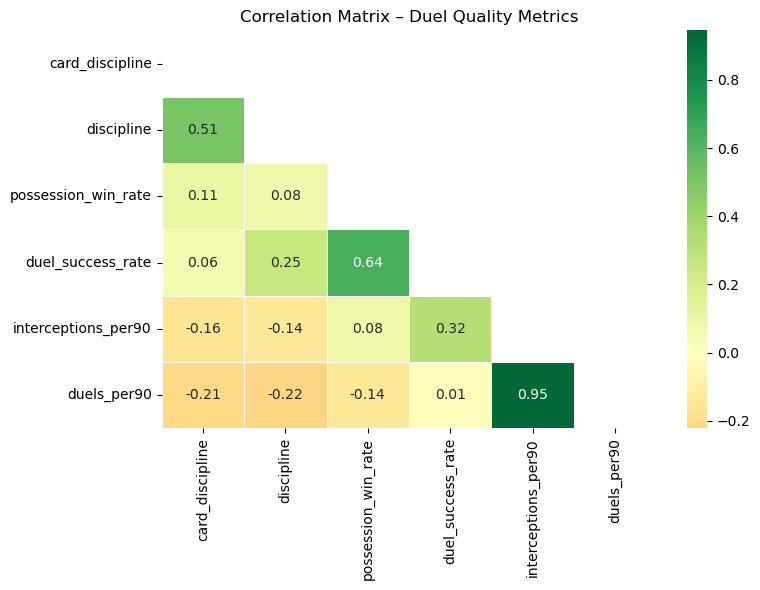

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = z_scores.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix – Duel Quality Metrics")
plt.tight_layout()
plt.show()

### Visualising Metric Distributions

Before combining metrics into a single score, it is useful to visualise how each normalised metric is distributed across all qualified players. This helps us spot outliers, check that z-scores look reasonable, and understand how spread out player performance is on each dimension. The custom `DistributionPlot` class overlays a highlighted marker for a specific player of interest.

In [87]:
import sys
sys.path.append(str(pathlib.Path().resolve().parents[0]))
from classes.visual import DistributionPlot

# Create distribution plot for z-scores
dist_plot = DistributionPlot(
    columns=metrics,
    labels=["Worse", "Average", "Above Average"]
)

# Add title
dist_plot.add_title(
    title="Center-Back Duel Quality Distirbution",
    subtitle=f"Based on {len(duel_summary)} players with ≥30 duels and >=350 minutes playing time"
)

# Convert z_scores to dataframe format expected by add_group_data
z_scores_df = z_scores.reset_index()

# Add all players as group data (background distribution)
dist_plot.add_group_data(
    df_plot=z_scores_df,
    plots="",  # No suffix needed since columns are already z-scores
    names=z_scores_df["player.name"],
    legend="All players",
    hover="",
    hover_string=""
)

# Highlight specific player (player.id = 370)
selected_player = z_scores_df[z_scores_df["player.id"] == 370]
if not selected_player.empty:
    player_name = selected_player["player.name"].iloc[0]
    dist_plot.add_data_point(
        ser_plot=selected_player.iloc[0],
        plots="",
        name=player_name,
        hover="",
        hover_string=""
    )

# For Jupyter notebooks, use this to display
dist_plot.fig.show()

## Quality Score

With all individual metrics normalised, we now aggregate them into a single composite **Duel Quality Index**. This index captures how well a center-back performs across all ground-duel dimensions — volume, success rate, possession recovery, and discipline — relative to all other qualifying center-backs in the dataset.

### Building the Composite Duel Quality Index

We combine all six normalised metrics into a single weighted score. The weights reflect the relative importance of each dimension: `possession_win_rate` receives the highest weight (35 %) because directly winning the ball back is the most valuable defensive outcome, while volume and discipline metrics play a supporting role. All weights sum to 1.0.

In [76]:
weights = {
    "duels_per90": 0.1,
    "interceptions_per90": 0.15,
    "duel_success_rate": 0.2,
    "possession_win_rate": 0.35,
    "discipline": 0.10,
    "card_discipline": 0.10
}

# Weighted sum: each metric's z-score is multiplied by its importance weight
duel_summary["Zq_raw"] = sum(
    z_scores[m] * w for m, w in weights.items()
)

### Normalising the Composite Score

The raw weighted sum (`Zq_raw`) already uses z-scored inputs, but its scale varies depending on the weights chosen. We re-standardise it to a final z-score (`duel_quality`) so that the output is always centred at 0 with a standard deviation of 1 — making it easy to compare players across seasons or leagues.

In [80]:
duel_summary["duel_quality"] = (
    (duel_summary["Zq_raw"] - duel_summary["Zq_raw"].mean())
) / duel_summary["Zq_raw"].std()

### Ranking Center-Backs by Duel Quality

We now sort all qualified center-backs by their composite `duel_quality` score in descending order to produce the final ranking. A higher z-score means the player performs better than the average of all center-backs on the overall duel quality index.

In [83]:
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline,duels_per90,interceptions_per90,stops_per90,Zq_raw,duel_quality
player.id,player.name,,,,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061,5.605263,3.815789,2.342105,0.040815,0.06724
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301,3.923559,2.660496,1.558674,-0.127442,-0.209954
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0,4.027027,3.000000,1.432432,0.825629,1.36018
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565,4.972973,3.216216,1.918919,-0.108067,-0.178035
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0,4.243243,3.027027,1.675676,0.38801,0.639226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520300,N. Wood,776.0,55,12,23,1,19,1,0,0.636364,0.218182,0.018182,0.981818,0.981818,6.378866,4.059278,2.667526,-0.303365,-0.499777
653730,A. Khusanov,504.0,30,4,16,1,9,1,0,0.666667,0.133333,0.033333,0.966667,0.966667,5.357143,3.571429,2.857143,-1.024361,-1.68758
327391,J. Bree,490.0,40,5,19,0,16,0,0,0.600000,0.125000,0.000000,1.000000,1.0,7.346939,4.408163,3.489796,-0.49758,-0.819736


In [85]:
cols = ["duel_quality"]
duel_summary.sort_values("duel_quality", ascending=False).head(15)

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline,duels_per90,interceptions_per90,stops_per90,Zq_raw,duel_quality
player.id,player.name,,,,,,,,,,,,,,,,,,
568412,J. Gvardiol,989.0,51,20,23,0,8,0,0,0.843137,0.392157,0.000000,1.000000,1.0,4.641052,3.913043,2.093023,1.354224,2.231013
349142,N. Mazraoui,856.0,104,33,39,3,29,0,0,0.692308,0.317308,0.028846,0.971154,1.0,10.934579,7.570093,4.100467,1.26135,2.078007
623641,E. Agbadou,1411.0,71,33,21,3,14,0,0,0.760563,0.464789,0.042254,0.957746,1.0,4.528703,3.444366,1.339476,1.201994,1.980222
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0,4.027027,3.000000,1.432432,0.825629,1.36018
645877,Y. Mosquera,442.0,34,10,16,1,7,0,0,0.764706,0.294118,0.029412,0.970588,1.0,6.923077,5.294118,3.257919,0.792353,1.30536
412968,M. Senesi,1105.0,131,39,50,8,34,2,0,0.679389,0.297710,0.061069,0.938931,0.984733,10.669683,7.248869,4.072398,0.733085,1.207718
424806,E. Pinnock,1916.0,109,36,43,0,30,0,0,0.724771,0.330275,0.000000,1.000000,1.0,5.120042,3.710856,2.019833,0.694937,1.144873
583655,C. Okoli,1134.0,86,26,38,2,20,1,0,0.744186,0.302326,0.023256,0.976744,0.988372,6.825397,5.079365,3.015873,0.650641,1.071897
283145,T. Adarabioyo,1377.0,68,24,24,0,20,0,0,0.705882,0.352941,0.000000,1.000000,1.0,4.444444,3.137255,1.568627,0.639302,1.053216


In [86]:
duel_summary["duel_quality"] \
    .sort_values(ascending=False) \
    .head(15)

player.id  player.name  
568412     J. Gvardiol      2.231013
349142     N. Mazraoui      2.078007
623641     E. Agbadou       1.980222
370        V. van Dijk       1.36018
645877     Y. Mosquera       1.30536
412968     M. Senesi        1.207718
424806     E. Pinnock       1.144873
583655     C. Okoli         1.071897
283145     T. Adarabioyo    1.053216
534563     C. Richards      1.024751
400549     Pau Torres       0.970251
590703     I. Zabarnyi      0.945072
447424     C. Bassey        0.942461
346131     T. Chalobah      0.930086
240032     J. Bednarek      0.887905
Name: duel_quality, dtype: object

### Aerial Duels

Aerial duel ability is the second defensive quality dimension we aim to measure. Here we explore the `aerialDuel.*` fields available in the Wyscout event data to understand how to extract and structure aerial contest information for center-backs. **Note:** this section is exploratory and the full aerial metric pipeline is in progress.

In [68]:
aerial_duels = cb_events[
    cb_events["aerialDuel.firstTouch"].notna()
]
aerial_duels

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent,location,aerialDuel.opponent,groundDuel.opponent
437,2384314191,5588197,1H,24,27,00:24:27.024,1468.024708,2.384314e+09,NaN,NaN,...,188.0,False,191.0,2.384314e+09,NaN,NaN,NaN,NaN,NaN,NaN
768,2384314484,5588197,1H,41,59,00:41:59.513,2520.513079,2.384314e+09,NaN,NaN,...,195.0,False,181.0,2.384314e+09,NaN,NaN,NaN,NaN,NaN,NaN
788,2384314499,5588197,1H,42,33,00:42:33.866,2554.866469,2.384314e+09,NaN,NaN,...,171.0,True,181.0,2.384314e+09,NaN,NaN,NaN,NaN,NaN,NaN
822,2384314264,5588197,1H,44,30,00:44:30.895,2671.895074,2.384314e+09,NaN,NaN,...,173.0,True,187.0,2.384315e+09,NaN,NaN,NaN,NaN,NaN,NaN
958,2384314361,5588197,2H,48,35,00:48:35.157,3119.157279,2.384314e+09,NaN,NaN,...,187.0,True,187.0,2.384315e+09,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630149,2395400950,5588229,2H,92,28,01:32:28.200,5629.2,2.395401e+09,NaN,NaN,...,NaN,False,187.0,2.395401e+09,NaN,NaN,NaN,NaN,NaN,NaN
630203,2395400913,5588229,2H,95,38,01:35:38.945,5819.945363,2.395401e+09,NaN,NaN,...,184.0,False,190.0,2.395401e+09,NaN,NaN,NaN,NaN,NaN,NaN
630208,2395400749,5588229,2H,96,12,01:36:12.790,5853.790884,2.395401e+09,NaN,NaN,...,192.0,True,187.0,2.395401e+09,NaN,NaN,NaN,NaN,NaN,NaN
630242,2395400790,5588229,2H,97,59,01:37:59.493,5960.493438,2.395401e+09,NaN,NaN,...,185.0,True,187.0,2.395401e+09,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
print(cb_events["aerialDuel.firstTouch"].notna().sum())
print(cb_events["aerialDuel.relatedDuelId"].notna().sum())
print(cb_events["aerialDuel.height"].notna().sum())

6727
6727
6727


In [70]:
ground = cb_events[cb_events["groundDuel"].notna()]

ground_stats = (
    ground.groupby("id")
    .agg(
        ground_duels=("groundDuel.duelType", "count"),
        ground_duels_won=("groundDuel.keptPossession", "sum")
    )
)

In [71]:
ground_duels = cb_events[cb_events["groundDuel"].notna()]